# Run Main Analysis

This notebook is a replication entry point. It runs the main workflow from `analysis/src/workflows.py`, regenerates the exported outputs, and then displays the key manuscript-facing tables and figures inline from `analysis/output/`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "analysis" / "src").exists()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Could not locate project root containing analysis/src.")

project_root = project_root.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)


In [2]:
from analysis.src.config import (
    DESCRIPTIVE_TABLE_PATH,
    MAIN_REGRESSION_TABLE_PATH,
    PREDICTIVE_CHECK_TABLE_PATH,
    MAIN_COEFFICIENT_FIGURE_PATH,
    GENRE_SELECTION_TABLE_PATH,
    WITHIN_GENRE_INTERACTION_TABLE_PATH,
    WITHIN_GENRE_JOINT_TEST_TABLE_PATH,
    WITHIN_GENRE_FOLLOWUP_TABLE_PATH,
    WITHIN_GENRE_PREDICTIVE_CHECK_TABLE_PATH,
    WITHIN_GENRE_FIGURE_PATH,
    GENRE_PROFILE_SUMMARY_TABLE_PATH,
    GENRE_DEVIATION_MODEL_TABLE_PATH,
    GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH,
    GENRE_DEVIATION_FIGURE_PATH,
)
from analysis.src.workflows import run_main_analysis_workflow


## Run Workflow

Run the Python workflow entry point first. All tables and figures displayed below are read back from the exported files generated by this workflow.

In [3]:
main_results = run_main_analysis_workflow(project_root)
main_results["sample_overview"]


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:257: RuntimeWarning: divide by zero encountered in divide
  return (2 * p - 1) / v ** 2
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:257: RuntimeWarning: overflow encountered in divide
  return (2 * p - 1) / v ** 2
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:576: RuntimeWarning: invalid value encountered in multiply
  tmp = score_factor * tmp
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:618: RuntimeWarning: invalid value encountered in multiply
  np.multiply(self.exog.T, factor, out=tmp.T)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:619: RuntimeWarning: invalid value encountered in dot
  return -tmp.T.dot(self.exog)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


{'primary_shape': (73442, 17),
 'robustness_shape': (89741, 19),
 'primary_audit': {'row_count': 73442,
  'unique_track_id_count': 73442,
  'duplicate_track_id_count': 0,
  'multi_genre_track_id_count': 0,
  'missingness_by_column': {'track_id': 0,
   'popularity': 0,
   'duration_ms': 0,
   'explicit': 0,
   'danceability': 0,
   'energy': 0,
   'key': 0,
   'loudness': 0,
   'mode': 0,
   'speechiness': 0,
   'acousticness': 0,
   'instrumentalness': 0,
   'liveness': 0,
   'valence': 0,
   'tempo': 0,
   'time_signature': 0,
   'track_genre': 0},
  'dtypes': {'track_id': 'object',
   'popularity': 'int64',
   'duration_ms': 'int64',
   'explicit': 'bool',
   'danceability': 'float64',
   'energy': 'float64',
   'key': 'int64',
   'loudness': 'float64',
   'mode': 'int64',
   'speechiness': 'float64',
   'acousticness': 'float64',
   'instrumentalness': 'float64',
   'liveness': 'float64',
   'valence': 'float64',
   'tempo': 'float64',
   'time_signature': 'int64',
   'track_genre':

## Generated Outputs

These are the key exported files that the notebook will preview inline.

In [4]:
def to_abs_path(relative_path):
    return (project_root / relative_path).resolve()


def show_table(relative_path, title, round_digits=3):
    path = to_abs_path(relative_path)
    frame = pd.read_csv(path)
    numeric_columns = frame.select_dtypes(include="number").columns
    display(Markdown(f"### {title}\n`{relative_path.as_posix()}`"))
    display(frame.round({column: round_digits for column in numeric_columns}))
    return frame


def show_figure(relative_path, title, width=900):
    path = to_abs_path(relative_path)
    display(Markdown(f"### {title}\n`{relative_path.as_posix()}`"))
    display(Image(filename=str(path), width=width))
    return path

output_manifest = pd.DataFrame(
    [
        {"section": "main", "kind": "table", "label": "Descriptive statistics", "path": DESCRIPTIVE_TABLE_PATH.as_posix()},
        {"section": "main", "kind": "table", "label": "Main regression table", "path": MAIN_REGRESSION_TABLE_PATH.as_posix()},
        {"section": "main", "kind": "table", "label": "Primary-sample predictive check", "path": PREDICTIVE_CHECK_TABLE_PATH.as_posix()},
        {"section": "within_genre", "kind": "table", "label": "Genre selection summary", "path": GENRE_SELECTION_TABLE_PATH.as_posix()},
        {"section": "within_genre", "kind": "table", "label": "Within-genre interaction table", "path": WITHIN_GENRE_INTERACTION_TABLE_PATH.as_posix()},
        {"section": "within_genre", "kind": "table", "label": "Joint interaction test", "path": WITHIN_GENRE_JOINT_TEST_TABLE_PATH.as_posix()},
        {"section": "within_genre", "kind": "table", "label": "Genre-specific follow-up table", "path": WITHIN_GENRE_FOLLOWUP_TABLE_PATH.as_posix()},
        {"section": "within_genre", "kind": "table", "label": "Selected-sample predictive check", "path": WITHIN_GENRE_PREDICTIVE_CHECK_TABLE_PATH.as_posix()},
        {"section": "deviation", "kind": "table", "label": "Genre profile summary", "path": GENRE_PROFILE_SUMMARY_TABLE_PATH.as_posix()},
        {"section": "deviation", "kind": "table", "label": "Genre-deviation model", "path": GENRE_DEVIATION_MODEL_TABLE_PATH.as_posix()},
        {"section": "deviation", "kind": "table", "label": "Genre-deviation robustness", "path": GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH.as_posix()},
        {"section": "main", "kind": "figure", "label": "Baseline pooled coefficient plot", "path": MAIN_COEFFICIENT_FIGURE_PATH.as_posix()},
        {"section": "within_genre", "kind": "figure", "label": "Within-genre feature comparison", "path": WITHIN_GENRE_FIGURE_PATH.as_posix()},
        {"section": "deviation", "kind": "figure", "label": "Genre-deviation effects", "path": GENRE_DEVIATION_FIGURE_PATH.as_posix()},
    ]
)
output_manifest


,section,kind,label,path
0,main,table,Descriptive statistics,analysis/output/tables/descriptive_statistics.csv
1,main,table,Main regression table,analysis/output/tables/main_regression_table.csv
2,main,table,Primary-sample predictive check,analysis/output/tables/predictive_check_summar...
3,within_genre,table,Genre selection summary,analysis/output/tables/genre_selection_table.csv
4,within_genre,table,Within-genre interaction table,analysis/output/tables/within_genre_interactio...
5,within_genre,table,Joint interaction test,analysis/output/tables/within_genre_joint_test...
6,within_genre,table,Genre-specific follow-up table,analysis/output/tables/within_genre_followup_t...
7,within_genre,table,Selected-sample predictive check,analysis/output/tables/within_genre_predictive...
8,deviation,table,Genre profile summary,analysis/output/tables/genre_profile_summary_t...
9,deviation,table,Genre-deviation model,analysis/output/tables/genre_deviation_model_t...


## Main Tables

In [5]:
_ = show_table(DESCRIPTIVE_TABLE_PATH, "Descriptive statistics")
_ = show_table(MAIN_REGRESSION_TABLE_PATH, "Main regression table")
_ = show_table(PREDICTIVE_CHECK_TABLE_PATH, "Primary-sample predictive check")


### Descriptive statistics
`analysis/output/tables/descriptive_statistics.csv`

,variable,n_obs,mean,std
0,sample_n,73442,73442.000,NaN
1,popularity,73442,32.463,19.017
2,duration_ms,73442,230073.974,118679.497
3,explicit,73442,0.086,0.280
4,key,73442,5.267,3.559
5,mode,73442,0.635,0.481
6,time_signature,73442,3.891,0.472
7,danceability,73442,0.559,0.180
8,energy,73442,0.630,0.261
9,loudness,73442,-8.704,5.393


### Main regression table
`analysis/output/tables/main_regression_table.csv`

,term,row_type,model_1_flag,model_2_flag,model_3_flag,model_1_coef,model_1_se,model_1_p_value,model_2_coef,model_2_se,model_2_p_value,model_3_coef,model_3_se,model_3_p_value
0,Key = 1,estimate,NaN,NaN,NaN,-0.666,0.311,0.032,0.249,0.241,0.301,0.255,0.241,0.290
1,Key = 2,estimate,NaN,NaN,NaN,-0.011,0.290,0.971,-0.228,0.223,0.306,-0.276,0.222,0.214
2,Key = 3,estimate,NaN,NaN,NaN,0.239,0.467,0.609,0.388,0.360,0.281,0.403,0.359,0.261
3,Key = 4,estimate,NaN,NaN,NaN,0.370,0.316,0.242,0.329,0.242,0.174,0.314,0.242,0.194
4,Key = 5,estimate,NaN,NaN,NaN,-0.004,0.324,0.990,0.107,0.254,0.674,0.098,0.253,0.698
5,Key = 6,estimate,NaN,NaN,NaN,0.021,0.348,0.951,0.153,0.273,0.576,0.189,0.272,0.487
6,Key = 7,estimate,NaN,NaN,NaN,-0.329,0.282,0.243,-0.171,0.218,0.431,-0.171,0.217,0.429
7,Key = 8,estimate,NaN,NaN,NaN,1.364,0.358,0.000,1.227,0.281,0.000,1.230,0.280,0.000
8,Key = 9,estimate,NaN,NaN,NaN,-0.254,0.297,0.391,-0.453,0.230,0.050,-0.437,0.230,0.057
9,Key = 10,estimate,NaN,NaN,NaN,-0.102,0.347,0.768,0.524,0.268,0.050,0.525,0.267,0.049


### Primary-sample predictive check
`analysis/output/tables/predictive_check_summary.csv`

,model_name,test_r2,test_rmse,n_train,n_test,train_group_count,test_group_count,group_overlap_count,r2_gain_vs_genre_control,rmse_reduction_vs_genre_control
0,genre_control,0.408,14.512,58753,14689,58753,14689,0,0.000,0.000
1,genre_control_plus_affective,0.411,14.477,58753,14689,58753,14689,0,0.003,0.034


## Within-Genre Results

In [6]:
_ = show_table(GENRE_SELECTION_TABLE_PATH, "Genre selection summary")
_ = show_table(WITHIN_GENRE_INTERACTION_TABLE_PATH, "Within-genre interaction table")
_ = show_table(WITHIN_GENRE_JOINT_TEST_TABLE_PATH, "Joint interaction test")
_ = show_table(WITHIN_GENRE_FOLLOWUP_TABLE_PATH, "Genre-specific follow-up table")
_ = show_table(WITHIN_GENRE_PREDICTIVE_CHECK_TABLE_PATH, "Selected-sample predictive check")


### Genre selection summary
`analysis/output/tables/genre_selection_table.csv`

,selection_rank,target_genre,manuscript_genre_label,selected_genre,n_tracks,selection_type,threshold_rule,market_rule,substitute_note
0,1,pop,pop,pop,412,exact,minimum n >= 400,market-relevant genre screen with explicit thr...,Exact dataset label used
1,2,rock,rock (dataset proxy: rock-n-roll),rock-n-roll,660,substitute,minimum n >= 400,market-relevant genre screen with explicit thr...,Selected as substitute for broader rock category
2,3,hip-hop,hip-hop,hip-hop,540,exact,minimum n >= 400,market-relevant genre screen with explicit thr...,Exact dataset label used
3,4,jazz,jazz,jazz,452,exact,minimum n >= 400,market-relevant genre screen with explicit thr...,Exact dataset label used
4,5,electronic,electronic,electronic,696,exact,minimum n >= 400,market-relevant genre screen with explicit thr...,Exact dataset label used


### Within-genre interaction table
`analysis/output/tables/within_genre_interaction_table.csv`

,term_group,term,coefficient,std_error,p_value,n_obs,adj_r2,selected_genres
0,control,Key = 1,0.077,1.650,0.963,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
1,control,Key = 2,-0.795,1.624,0.625,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
2,control,Key = 3,2.005,2.433,0.410,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
3,control,Key = 4,1.004,1.749,0.566,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
4,control,Key = 5,0.023,1.717,0.990,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
5,control,Key = 6,-7.532,2.140,0.000,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
6,control,Key = 7,0.699,1.637,0.669,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
7,control,Key = 8,0.494,2.295,0.830,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
8,control,Key = 9,-1.989,1.571,0.206,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic
9,control,Key = 10,-0.679,2.108,0.747,2760,0.338,pop | rock-n-roll | hip-hop | jazz | electronic


### Joint interaction test
`analysis/output/tables/within_genre_joint_test_table.csv`

,test_type,statistic,df,p_value,term_count
0,Wald chi-square,83.05,12,0.0,12


### Genre-specific follow-up table
`analysis/output/tables/within_genre_followup_table.csv`

,genre,term,coefficient,std_error,p_value,n_obs,adj_r2,q_value,fdr_reject
0,pop,Dance orientation (z),3.276,2.120,0.122,412.0,0.133,0.262,False
1,pop,Sonic intensity (z),-1.135,2.390,0.635,412.0,0.133,0.732,False
2,pop,Positive affect (z),-1.185,2.303,0.607,412.0,0.133,0.732,False
3,rock-n-roll,Dance orientation (z),0.331,0.333,0.320,660.0,-0.007,0.470,False
4,rock-n-roll,Sonic intensity (z),0.110,0.361,0.762,660.0,-0.007,0.816,False
5,rock-n-roll,Positive affect (z),0.412,0.436,0.345,660.0,-0.007,0.470,False
6,hip-hop,Dance orientation (z),-1.783,1.409,0.206,540.0,0.312,0.385,False
7,hip-hop,Sonic intensity (z),3.037,1.245,0.015,540.0,0.312,0.055,False
8,hip-hop,Positive affect (z),-0.050,1.330,0.970,540.0,0.312,0.970,False
9,jazz,Dance orientation (z),6.238,1.647,0.000,452.0,0.188,0.002,True


### Selected-sample predictive check
`analysis/output/tables/within_genre_predictive_check_table.csv`

,model_name,test_r2,test_rmse,n_train,n_test,group_overlap_count,r2_gain_vs_no_interaction,rmse_reduction_vs_no_interaction
0,no_interaction,0.304,20.677,2208,552,0,0.000,0.000
1,interaction_aware,0.333,20.236,2208,552,0,0.029,0.441


## Genre-Relative Deviation Results

In [7]:
_ = show_table(GENRE_PROFILE_SUMMARY_TABLE_PATH, "Genre profile summary")
_ = show_table(GENRE_DEVIATION_MODEL_TABLE_PATH, "Genre-deviation model")
_ = show_table(GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH, "Genre-deviation robustness")


### Genre profile summary
`analysis/output/tables/genre_profile_summary_table.csv`

,genre,feature,genre_mean,genre_std,n_obs
0,pop,danceability,0.580,0.140,412
1,rock-n-roll,danceability,0.550,0.139,660
2,hip-hop,danceability,0.724,0.127,540
3,jazz,danceability,0.488,0.149,452
4,electronic,danceability,0.659,0.130,696
5,pop,energy,0.578,0.201,412
6,rock-n-roll,energy,0.507,0.170,660
7,hip-hop,energy,0.690,0.142,540
8,jazz,energy,0.306,0.166,452
9,electronic,energy,0.694,0.185,696


### Genre-deviation model
`analysis/output/tables/genre_deviation_model_table.csv`

,term_group,term,coefficient,std_error,p_value,n_obs,adj_r2
0,control,Key = 1,-0.876,1.672,0.600,2760.0,0.322
1,control,Key = 2,-0.389,1.672,0.816,2760.0,0.322
2,control,Key = 3,1.463,2.369,0.537,2760.0,0.322
3,control,Key = 4,1.107,1.794,0.537,2760.0,0.322
4,control,Key = 5,0.006,1.728,0.997,2760.0,0.322
5,control,Key = 6,-7.900,2.146,0.000,2760.0,0.322
6,control,Key = 7,1.471,1.619,0.364,2760.0,0.322
7,control,Key = 8,0.734,2.332,0.753,2760.0,0.322
8,control,Key = 9,-1.668,1.609,0.300,2760.0,0.322
9,control,Key = 10,0.221,2.154,0.918,2760.0,0.322


### Genre-deviation robustness
`analysis/output/tables/genre_deviation_robustness_table.csv`

,term_group,term,coefficient,std_error,p_value,n_obs,adj_r2
0,control,Key = 1,-0.909,1.684,0.590,2760.0,0.314
1,control,Key = 2,-0.743,1.684,0.659,2760.0,0.314
2,control,Key = 3,1.694,2.365,0.474,2760.0,0.314
3,control,Key = 4,1.127,1.776,0.526,2760.0,0.314
4,control,Key = 5,0.184,1.727,0.915,2760.0,0.314
5,control,Key = 6,-7.945,2.190,0.000,2760.0,0.314
6,control,Key = 7,1.255,1.634,0.442,2760.0,0.314
7,control,Key = 8,0.783,2.312,0.735,2760.0,0.314
8,control,Key = 9,-2.052,1.608,0.202,2760.0,0.314
9,control,Key = 10,0.231,2.167,0.915,2760.0,0.314


## Figures

### Baseline pooled coefficient plot
`analysis/output/figures/main_coefficient_plot.png`

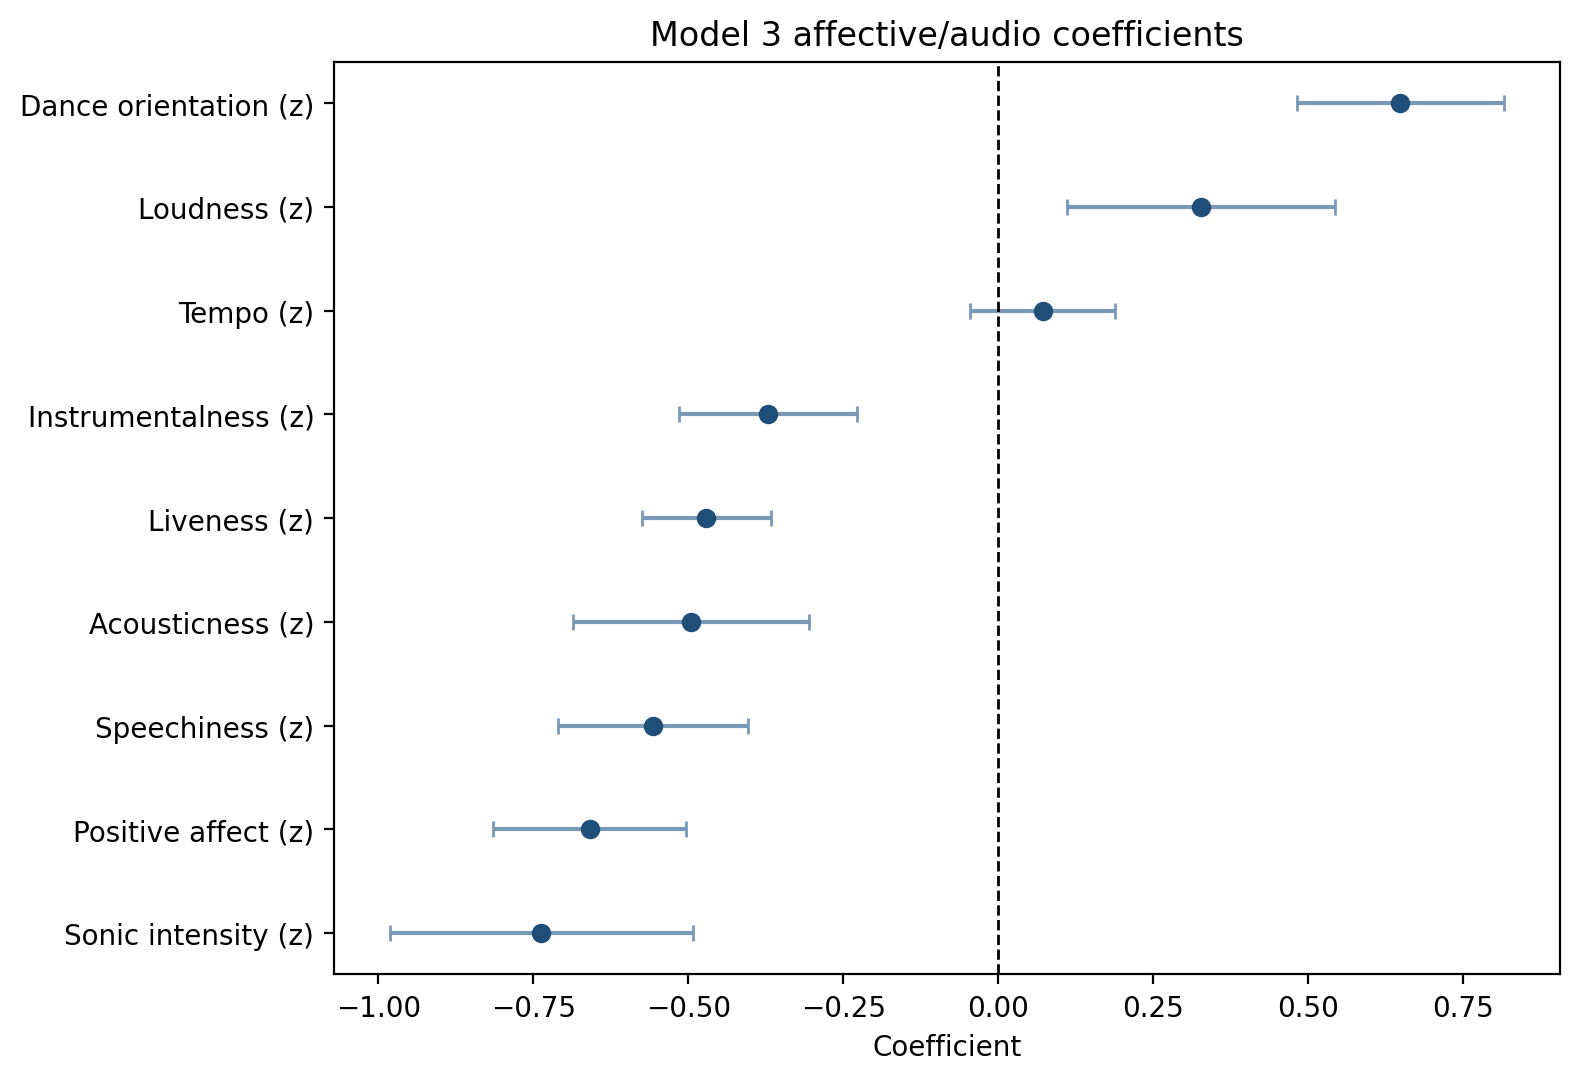

### Within-genre feature comparison
`analysis/output/figures/within_genre_feature_comparison.png`

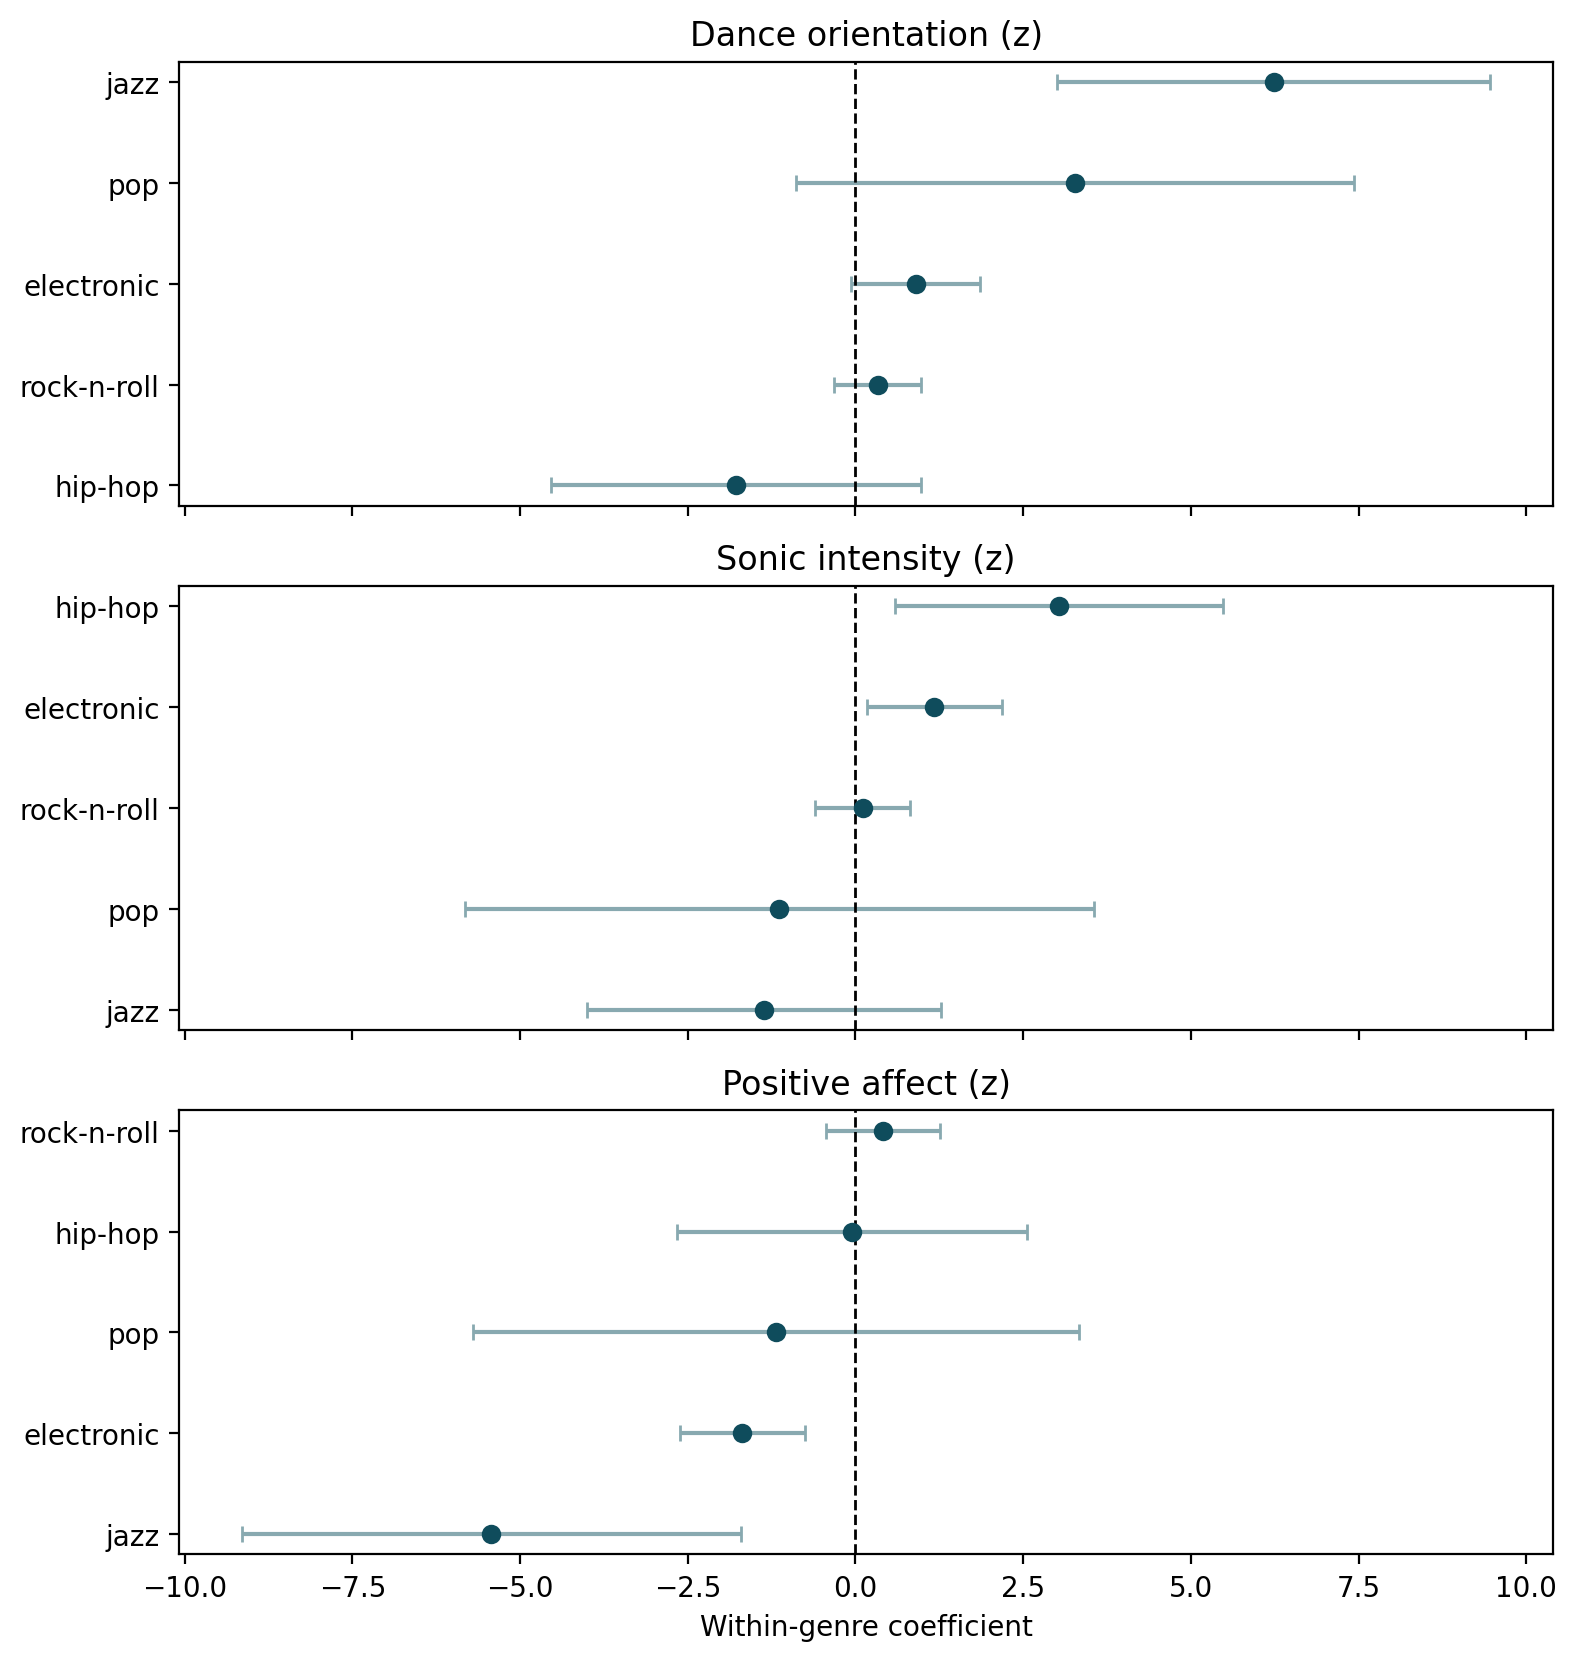

### Genre-deviation effects
`analysis/output/figures/genre_deviation_effects.png`

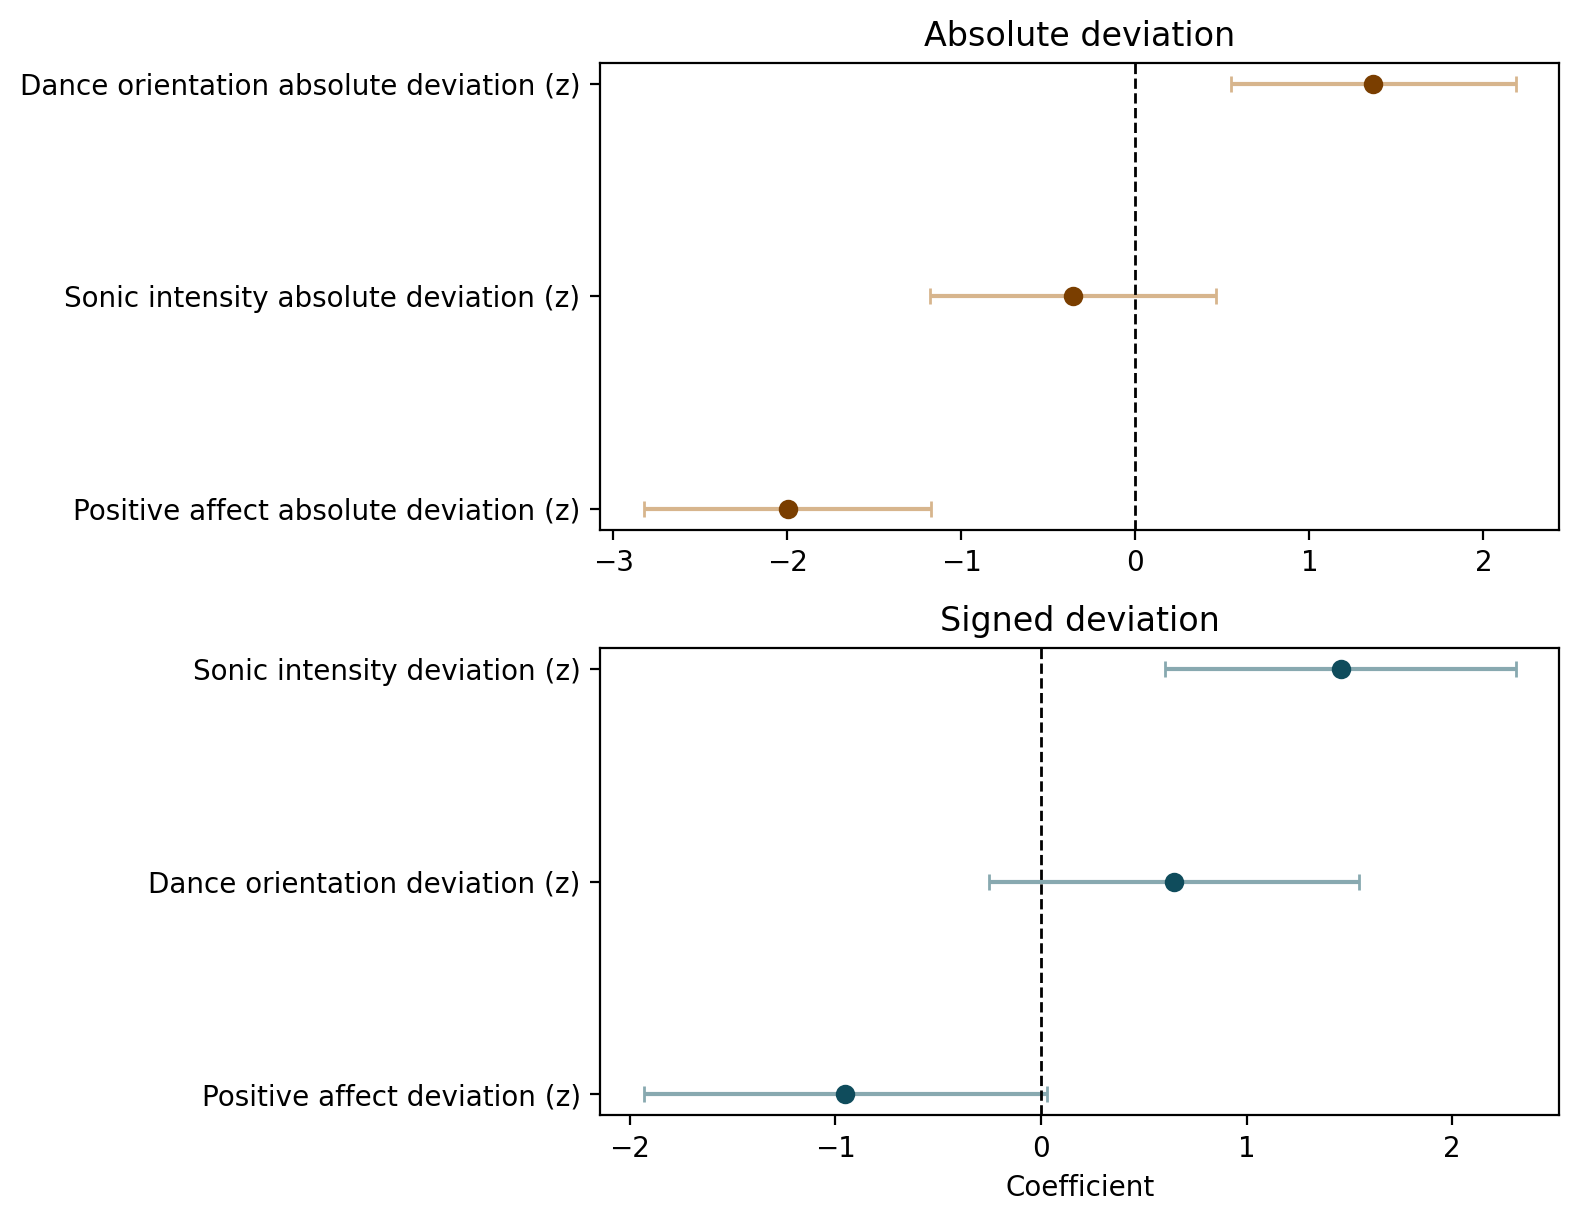

In [8]:
_ = show_figure(MAIN_COEFFICIENT_FIGURE_PATH, "Baseline pooled coefficient plot")
_ = show_figure(WITHIN_GENRE_FIGURE_PATH, "Within-genre feature comparison")
_ = show_figure(GENRE_DEVIATION_FIGURE_PATH, "Genre-deviation effects")
